In [16]:
from dotenv import load_dotenv
load_dotenv()

True

In [48]:
from langgraph.graph import START , END , StateGraph 
from langchain_groq import ChatGroq 
from pydantic import BaseModel 
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal

In [18]:
class MailState(BaseModel):
    query : str = ""
    draft : str = ""
    human_feedback : str = ""
    final_response : str = ""

#### LLM MODEL 

In [7]:
llm = ChatGroq(model="openai/gpt-oss-20b")

#### DEFINING THE NODES - DRAFT EMAIL , HUMAN FB and SEND 

In [ ]:
def DraftEmail(state:MailState) -> MailState: 
    if state.human_feedback:
        draft = llm.invoke(f"""
                Rewrite this draft email for {state.query}
                You have generated this mail: {state.draft},
                Human feedback to apply : {state.human_feedback},
                
        
        """).content
    else :
        draft = llm.invoke(state.query).content
    state.draft = draft
    return state


def HumanFeedback(state:MailState) -> MailState: 
    feedback = interrupt({
        "draft_email": state.draft,
        "question":"Do you want to continue or re-write the mail?"
    })
    
    fb = (feedback or "").strip().lower()
    if fb in ("approved","ok","yes"):
        state.human_feedback = ""
        return state 
    
    else:
        state.human_feedback = feedback 
        return state 
    
    
def SendEmail(state:MailState) -> MailState : 
        if state.human_feedback:
            state.final_response = state.human_feedback 
            return state 
        
        else: 
            print("Email Sent Successfully.....")
            state.final_response = "Email Sent Successfully"
            return state 
        
        

def condition_routing(state:MailState) -> Literal["draft","send_email"]:
    if state.human_feedback:
        return "draft"
    return "final"
    
    

In [53]:
graph = StateGraph(MailState)

graph.add_node("draft", DraftEmail)
graph.add_node("human_fb", HumanFeedback)
graph.add_node("send_email", SendEmail)

graph.add_edge(START , "draft")
graph.add_edge("draft","human_fb")
graph.add_conditional_edges("human_fb", condition_routing)
graph.add_edge("send_email", END)

graph = graph.compile(checkpointer=InMemorySaver())



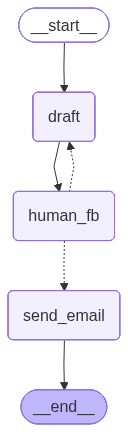

In [54]:
from IPython.display import Image 
Image(graph.get_graph().draw_mermaid_png())

In [26]:
config = {"configurable":{"thread_id":"1"}}

In [55]:
res = graph.invoke({"query":"I want to send an email for Medical Leave Request. dates will be from 22 June to 5 July,"
                    "so create a simple email for the same"}, config=config)

In [57]:
print(res["draft"])

**Subject:** Medical Leave Request (22 June – 5 July)

Dear [Supervisor’s Name],

I am writing to formally request medical leave from **22 June 2024 to 5 July 2024** due to a health condition that requires rest and treatment. I will ensure that all urgent tasks are delegated and that my responsibilities are covered during my absence.

Please let me know if you need any additional documentation or if there are forms I should complete.

Thank you for your understanding.

Best regards,

[Your Full Name]  
[Your Job Title]  
[Your Department]  
[Your Phone Number]  
[Your Email Address]


In [58]:
res = graph.invoke(Command(resume="I want to change the date from 22 June to 24 June"), config=config)

In [59]:
print(res["draft"])

**Subject:** Medical Leave Request (22 June – 24 June)

Dear [Supervisor’s Name],

I hope you are well. I am writing to request medical leave from **22 June 2024 to 24 June 2024**. I will ensure that all urgent tasks are delegated and that my responsibilities are covered during my absence.  

Please let me know if you need any documentation or if there are forms I should complete.

Thank you for your understanding.

Best regards,

[Your Full Name]  
[Your Job Title]  
[Your Department]  
[Your Phone Number]  
[Your Email Address]
